# Compare sPHENIX $K_S^0$ $R\,m/p_T$ to the ALICE $c\tau$ distribution

This notebook overlays a selected sPHENIX $p_T$ interval on a digitized version of the ALICE $K_S^0$ distribution shown in the supplied figure.

For the sPHENIX TH3 we use
$$c\tau_T = R\,\frac{m_{\pi\pi}}{p_T^{V0}},$$
because the stored displacement is the transverse decay radius $R$ and the stored momentum is $p_T$.

The ALICE reference plot uses $L\,m/p$.  For a midrapidity sample, $R\,m/p_T$ is the corresponding transverse quantity and should have the same lifetime scale for an ideal reconstruction.

**ALICE reference:** arXiv:1012.3257. The plotted open-circle $K_S^0$ points below are digitized approximately from the published figure; the published exponential slope is $2.72\pm0.03$ cm.


In [1]:
import ROOT as root
import math
from array import array

root.gStyle.SetOptStat(0)
root.gStyle.SetOptFit(1111)
#root.gROOT.SetBatch(False)

# ---------------------------------------------------------------
# USER SETTINGS
# ---------------------------------------------------------------
FILE_NAME = "input/k0s_double_peak_stream_v0.root"
HIST_NAME = "h_decay_radius_vs_mass_vs_pt"

# K0S signal mass window
MASS_MIN = 0.490
MASS_MAX = 0.505

# Select the sPHENIX pT bin here
PT_MIN = 0.7
PT_MAX = 5.0

# Proper-decay-length histogram
CTAU_MIN = 0.0
CTAU_MAX = 50.0
N_CTAU_BINS = 100

# Overlay normalization:
#   "area"     -> equal area in a chosen comparison range
#   "point"    -> match at NORMALIZE_AT_X
#   "none"     -> raw sPHENIX counts
NORMALIZATION = "area"
NORMALIZE_XMIN = 2.0
NORMALIZE_XMAX = 12.0
NORMALIZE_AT_X = 4.0

K0S_CTAU_PDG = 2.6844
ALICE_FIT_CTAU = 2.72


Welcome to JupyROOT 6.30/06


## Digitized ALICE $K_S^0$ reference

These are approximate points read from the open-circle $K_S^0$ distribution in the ALICE figure.  They are meant for a shape/lifetime comparison, not for a precision numerical re-analysis of the published data.


In [2]:
alice_x = [0.5, 0.9, 1.3, 1.7, 2.1, 2.5, 2.9, 3.3, 3.7, 4.1, 4.6, 5.1, 5.6, 6.2, 6.8, 7.4, 8.0, 8.6, 9.2, 9.8, 10.4, 11.0, 11.6, 12.2, 12.8, 13.4, 14.0, 14.6, 15.2, 15.8, 16.4, 17.0]
alice_y = [820, 760, 680, 610, 535, 465, 405, 350, 300, 255, 215, 180, 150, 125, 104, 86, 70, 57, 46, 37, 30, 24, 19, 15, 12, 9.5, 7.5, 5.9, 4.6, 3.6, 2.8, 2.1]

g_alice = root.TGraph(len(alice_x), array('d', alice_x), array('d', alice_y))
g_alice.SetName("g_alice_k0s_digitized")
g_alice.SetTitle("ALICE K^{0}_{S} digitized")
g_alice.SetMarkerStyle(24)   # open circle
g_alice.SetMarkerSize(1.05)
g_alice.SetLineWidth(1)

# Published ALICE exponential slope = 2.72 cm.
# Normalization chosen only to pass through the digitized reference points.
ALICE_A = 900.0
f_alice = root.TF1("f_alice", f"{ALICE_A}*exp(-x/{ALICE_FIT_CTAU})", 0.0, 50.0)
f_alice.SetLineWidth(2)
f_alice.SetLineStyle(1)


## Load the sPHENIX TH3


In [3]:
def find_object_recursive(directory, object_name):
    obj = directory.Get(object_name)
    if obj:
        return obj
    for key in directory.GetListOfKeys():
        item = key.ReadObj()
        if item.InheritsFrom("TDirectory"):
            found = find_object_recursive(item, object_name)
            if found:
                return found
    return None

f = root.TFile.Open(FILE_NAME, "READ")
if not f or f.IsZombie():
    raise RuntimeError(f"Cannot open {FILE_NAME}")

h3 = find_object_recursive(f, HIST_NAME)
if not h3:
    raise RuntimeError(f"Could not find '{HIST_NAME}'")
if not h3.InheritsFrom("TH3"):
    raise TypeError(f"'{HIST_NAME}' is not a TH3")

print("Found", h3.GetName(), "with", h3.GetEntries(), "entries")
print("x:", h3.GetXaxis().GetTitle())
print("y:", h3.GetYaxis().GetTitle())
print("z:", h3.GetZaxis().GetTitle())


Found h_decay_radius_vs_mass_vs_pt with 2071715.0 entries
x:  m_{#pi#pi} [GeV/c^{2}]
y:  p_{T}^{V0} [GeV/c]
z:  decay radius [cm]


## Build $R\,m/p_T$ only for the selected $p_T$ interval


In [4]:
xax = h3.GetXaxis()   # m_pipi
yax = h3.GetYaxis()   # pT(V0)
zax = h3.GetZaxis()   # decay radius R

h_us = root.TH1D(
    "h_us_ctau_selected_pt",
    f"sPHENIX, {PT_MIN:.2f}<p_{{T}}^{{V0}}<{PT_MAX:.2f} GeV/c;R m_{{#pi#pi}}/p_{{T}}^{{V0}} [cm];Counts",
    N_CTAU_BINS, CTAU_MIN, CTAU_MAX
)
h_us.Sumw2()

for ix in range(1, xax.GetNbins() + 1):
    mass = xax.GetBinCenter(ix)
    if not (MASS_MIN <= mass < MASS_MAX):
        continue

    for iy in range(1, yax.GetNbins() + 1):
        pt = yax.GetBinCenter(iy)
        if pt <= 0 or not (PT_MIN <= pt < PT_MAX):
            continue

        for iz in range(1, zax.GetNbins() + 1):
            w = h3.GetBinContent(ix, iy, iz)
            if w <= 0:
                continue
            R = zax.GetBinCenter(iz)
            ctau_t = R * mass / pt
            h_us.Fill(ctau_t, w)

print("Selected weighted candidates:", h_us.Integral())


Selected weighted candidates: 240577.0


## Normalize sPHENIX to the ALICE reference for an overlay

Because the ALICE published plot and your histogram contain completely different event samples, an absolute count comparison is not meaningful.  By default the code scales the sPHENIX distribution to the same integral as the digitized ALICE distribution over `NORMALIZE_XMIN`--`NORMALIZE_XMAX`.


In [5]:
def alice_integral_graph(xmin, xmax):
    total = 0.0
    for x, y in zip(alice_x, alice_y):
        if xmin <= x < xmax:
            total += y
    return total

h_us_plot = h_us.Clone("h_us_ctau_selected_pt_scaled")

if NORMALIZATION == "area":
    b1 = h_us_plot.FindBin(NORMALIZE_XMIN + 1e-9)
    b2 = h_us_plot.FindBin(NORMALIZE_XMAX - 1e-9)
    us_int = h_us_plot.Integral(b1, b2)
    alice_int = alice_integral_graph(NORMALIZE_XMIN, NORMALIZE_XMAX)
    if us_int > 0 and alice_int > 0:
        h_us_plot.Scale(alice_int / us_int)
        print("Area-normalization scale =", alice_int / us_int)

elif NORMALIZATION == "point":
    us_y = h_us_plot.GetBinContent(h_us_plot.FindBin(NORMALIZE_AT_X))
    alice_y_at_x = ALICE_A * math.exp(-NORMALIZE_AT_X / ALICE_FIT_CTAU)
    if us_y > 0:
        h_us_plot.Scale(alice_y_at_x / us_y)
        print("Point-normalization scale =", alice_y_at_x / us_y)

elif NORMALIZATION == "none":
    pass
else:
    raise ValueError("NORMALIZATION must be 'area', 'point', or 'none'")


Area-normalization scale = 0.018775998477474784


## Overlay: ALICE digitization + selected sPHENIX $p_T$ bin


Info in <TCanvas::Print>: pdf file alice_sphenix_k0s_ctau_overlay.pdf has been created
Info in <TCanvas::Print>: png file alice_sphenix_k0s_ctau_overlay.png has been created


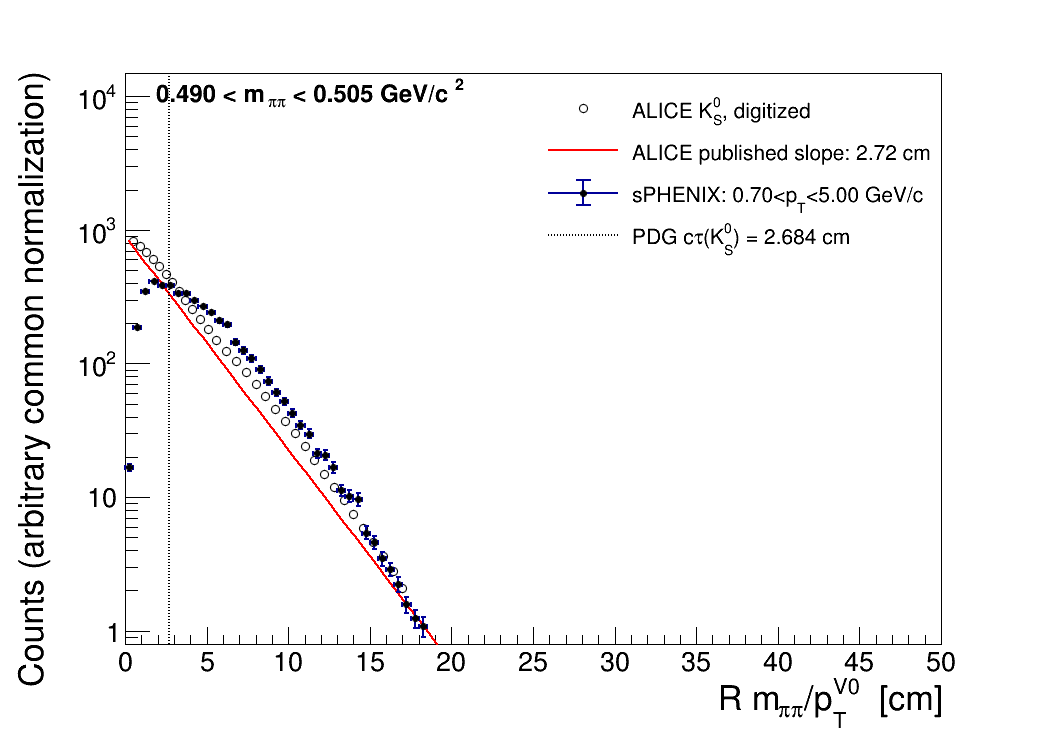

In [6]:
c_overlay = root.TCanvas("c_overlay", "ALICE vs sPHENIX", 1050, 760)
c_overlay.SetLogy()
c_overlay.SetLeftMargin(0.12)
c_overlay.SetBottomMargin(0.12)

frame = c_overlay.DrawFrame(0.0, 0.8, 50.0, 1.5e4)
frame.SetTitle("")
frame.GetXaxis().SetTitle("R m_{#pi#pi}/p_{T}^{V0}  [cm]")
frame.GetYaxis().SetTitle("Counts (arbitrary common normalization)")
frame.GetXaxis().SetTitleSize(0.050)
frame.GetYaxis().SetTitleSize(0.050)
frame.GetXaxis().SetLabelSize(0.040)
frame.GetYaxis().SetLabelSize(0.040)

g_alice.Draw("P SAME")
f_alice.Draw("SAME")

h_us_plot.SetMarkerStyle(20)
h_us_plot.SetMarkerSize(0.85)
h_us_plot.SetLineWidth(2)
h_us_plot.Draw("E1 SAME")

# PDG lifetime marker
line_pdg = root.TLine(K0S_CTAU_PDG, 0.8, K0S_CTAU_PDG, 1.5e4)
line_pdg.SetLineStyle(3)
line_pdg.SetLineWidth(2)
line_pdg.Draw()

leg = root.TLegend(0.51, 0.65, 0.89, 0.88)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.AddEntry(g_alice, "ALICE K^{0}_{S}, digitized", "p")
leg.AddEntry(f_alice, "ALICE published slope: 2.72 cm", "l")
leg.AddEntry(h_us_plot, f"sPHENIX: {PT_MIN:.2f}<p_{{T}}<{PT_MAX:.2f} GeV/c", "lep")
leg.AddEntry(line_pdg, "PDG c#tau(K^{0}_{S}) = 2.684 cm", "l")
leg.Draw()

latex = root.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.036)
latex.DrawLatex(0.15, 0.86, f"{MASS_MIN:.3f} < m_{{#pi#pi}} < {MASS_MAX:.3f} GeV/c^{{2}}")

c_overlay.Draw()
c_overlay.SaveAs("alice_sphenix_k0s_ctau_overlay.pdf")
c_overlay.SaveAs("alice_sphenix_k0s_ctau_overlay.png")


## Optional: fit the selected sPHENIX interval

Choose `FIT_MIN` above the low-radius efficiency turn-on.  The fitted parameter `[1]` is the effective decay-length slope in cm.


In [7]:
FIT_MIN = 3.0
FIT_MAX = 15.0

f_us = root.TF1("f_us", "[0]*exp(-x/[1])", FIT_MIN, FIT_MAX)
f_us.SetParameters(max(1.0, h_us.GetMaximum()), K0S_CTAU_PDG)
f_us.SetParNames("Normalization", "slope [cm]")
fit_result = h_us.Fit(f_us, "SR")

print(f"sPHENIX selected-bin slope = {f_us.GetParameter(1):.4f} +/- {f_us.GetParError(1):.4f} cm")
print(f"ALICE published slope       = {ALICE_FIT_CTAU:.4f} cm")
print(f"PDG K0S c*tau              = {K0S_CTAU_PDG:.4f} cm")


sPHENIX selected-bin slope = 2.9416 +/- 0.0287 cm
ALICE published slope       = 2.7200 cm
PDG K0S c*tau              = 2.6844 cm
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      147.618
NDf                       =           22
Edm                       =   6.2677e-09
NCalls                    =           86
Normalization             =      68619.5   +/-   1831.54     
slope [cm]                =      2.94158   +/-   0.0286738   
